# Тема 2. Визуальный анализ данных

## Дополнительные материалы (самостоятельное чтение)

На занятии не разбираем. Четыре темы:

1. `DataFrame.plot()` — быстрый график прямо из pandas, без seaborn/matplotlib
2. `jointplot(kind="kde")` — сглаженная версия scatter+гистограмм с занятия
3. Plotly — интерактивные графики (можно приближать, наводить мышью)
4. Взгляд на весь датасет сразу: naive pairplot vs. понижение размерности (PCA, t-SNE)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set()
%config InlineBackend.figure_format = 'svg'

df = pd.read_csv("../data/telecom_churn.csv")
df["Churn"] = df["Churn"].astype("int64")
df.head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,0
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,0
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,0
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,0
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,0


---
## 1. `DataFrame.plot()`

У каждого `DataFrame`/`Series` есть встроенный метод `.plot()` — обёртка над matplotlib. Быстро, но менее гибко и менее красиво, чем seaborn. Полезно для одноразового взгляда на данные без импорта лишних библиотек.

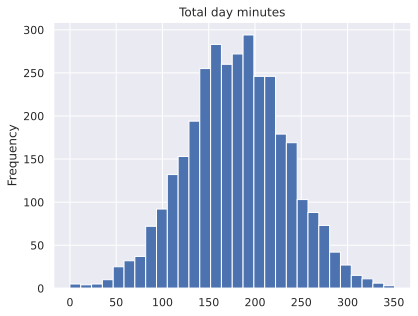

In [2]:
df["Total day minutes"].plot(kind="hist", bins=30, title="Total day minutes");

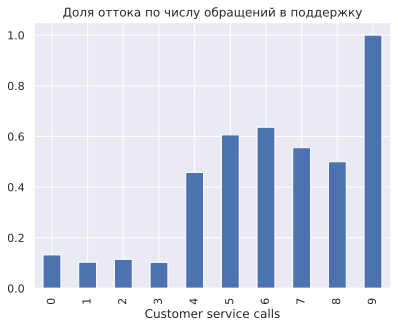

In [3]:
df.groupby("Customer service calls")["Churn"].mean().plot(
    kind="bar", title="Доля оттока по числу обращений в поддержку"
);

`kind` поддерживает: `line`, `bar`, `barh`, `hist`, `box`, `kde`/`density`, `area`, `pie`, `scatter`, `hexbin`. Для разведочного анализа с несколькими признаками сразу и цветовым кодированием по классу — удобнее seaborn (см. `lesson02_visual_theory.ipynb`).

---
## 2. `jointplot(kind="kde")`

На занятии строили `sns.jointplot(..., kind="scatter")` для `Total day minutes` vs `Total night minutes`. Есть и KDE-версия — вместо отдельных точек рисует сглаженную «тепловую карту» плотности точек, иногда так удобнее увидеть, где концентрация наблюдений плотнее:

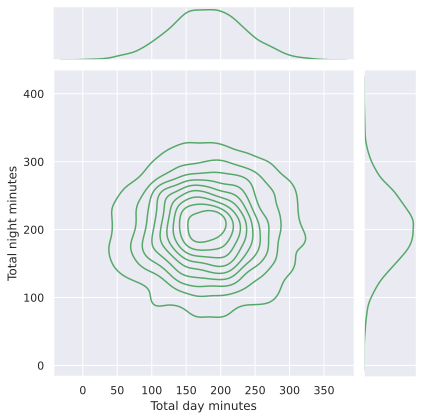

In [4]:
sns.jointplot(x="Total day minutes", y="Total night minutes", data=df, kind="kde", color="g");

---
## 3. Plotly — интерактивные графики

В отличие от matplotlib/seaborn, Plotly рисует интерактивную картинку: можно приближать, наводить мышью и видеть точные значения, скрывать серии кликом по легенде. Полезно для дашбордов и когда график нужно передать не-технической аудитории для самостоятельного изучения.

In [5]:
import plotly.express as px

fig = px.scatter(
    df, x="Total day minutes", y="Total night minutes", color="Churn", opacity=0.5,
    title="Total day vs night minutes, по оттоку",
)
fig.show()

In [6]:
fig = px.box(df, x="Churn", y="Total day minutes", title="Total day minutes по оттоку")
fig.show()

Синтаксис `plotly.express` намеренно похож на seaborn — `x`, `y`, `color` вместо `hue`. Обратная сторона интерактивности — такие графики тяжелее (JS в каждой ячейке), поэтому в статичном отчёте или большом ноутбуке лучше matplotlib/seaborn, а Plotly — точечно, для 1-2 ключевых интерактивных графиков.

---
## 4. Взгляд на весь датасет сразу

### 4.1 Наивный способ: pairplot

Мы уже строили `pairplot` по отобранным вручную признакам. А что, если признаков много и вручную не отобрать? `pairplot` на все признаки сразу становится нечитаемым — $n$ признаков дают $n^2$ маленьких графиков.

### 4.2 Понижение размерности

Альтернатива — сжать все числовые признаки в 2 «синтетических» измерения так, чтобы точки, похожие по исходным признакам, остались близко и на плоскости. Это не даёт интерпретируемых осей («ось X — это что?» — на такой вопрос обычно нет хорошего ответа), но позволяет **на глаз** оценить, есть ли в данных выраженная кластерная структура.

**PCA (Principal Component Analysis)** — линейный метод, ищет направления наибольшей дисперсии данных.

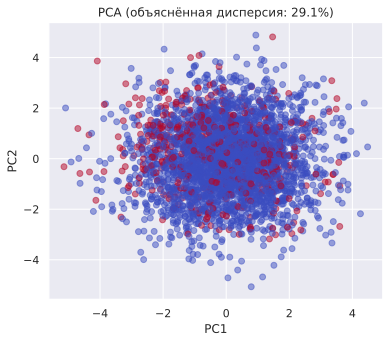

In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

numerical = list(
    set(df.columns)
    - {"State", "International plan", "Voice mail plan", "Area code", "Churn", "Customer service calls"}
)
X = StandardScaler().fit_transform(df[numerical])

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(6, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df["Churn"], cmap="coolwarm", alpha=0.5)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"PCA (объяснённая дисперсия: {pca.explained_variance_ratio_.sum():.1%})");

Первые 2 компоненты объясняют только около 29% дисперсии — небольшой процент, а разделения между классами не видно. Это тоже результат: значит, признаки в этом датасете относительно независимы (мы уже видели это по корреляционной матрице в теории), и **линейного** сжатия в 2D недостаточно, чтобы увидеть структуру, если она вообще там есть в простом виде.

**t-SNE** — нелинейный метод, часто вытаскивает кластерную структуру там, где PCA не справляется (ценой того, что оси и расстояния между кластерами не имеют количественного смысла — только взаимное расположение точек). Работает медленнее, поэтому возьмём случайную подвыборку:

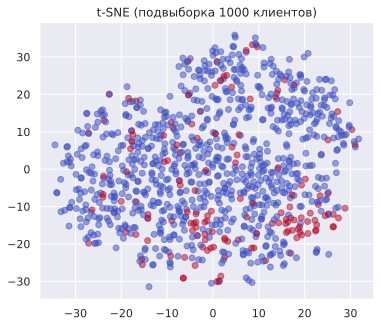

In [8]:
from sklearn.manifold import TSNE

sample = df.sample(1000, random_state=42)
X_sample = StandardScaler().fit_transform(sample[numerical])

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_sample)

plt.figure(figsize=(6, 5))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=sample["Churn"], cmap="coolwarm", alpha=0.5)
plt.title("t-SNE (подвыборка 1000 клиентов)");

Тоже без выраженных отдельных кластеров по оттоку — согласуется с тем, что мы видели в `pairplot` и box plot по классам: сигнал в данных есть (`Customer service calls`, `International plan` явно связаны с `Churn`), но он не выражается в виде чётких визуальных кластеров на 2D-проекции всех признаков сразу. Это нормально — большинство реальных задач классификации выглядят именно так, не как аккуратно разделённые облака точек.

PCA и t-SNE подробнее разберём, когда дойдём до тем про обучение без учителя.

---
## Итог

Дальше в курсе — первые модели машинного обучения (`lesson02_visual_theory.ipynb` → `lesson02_visual_practice.ipynb`, а затем деревья решений).